# importing the nessecery madules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### reading data from csv file (fuel consumption)

In [2]:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


### select the needed columns

In [3]:
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


### making a scatter plots for the all the columns

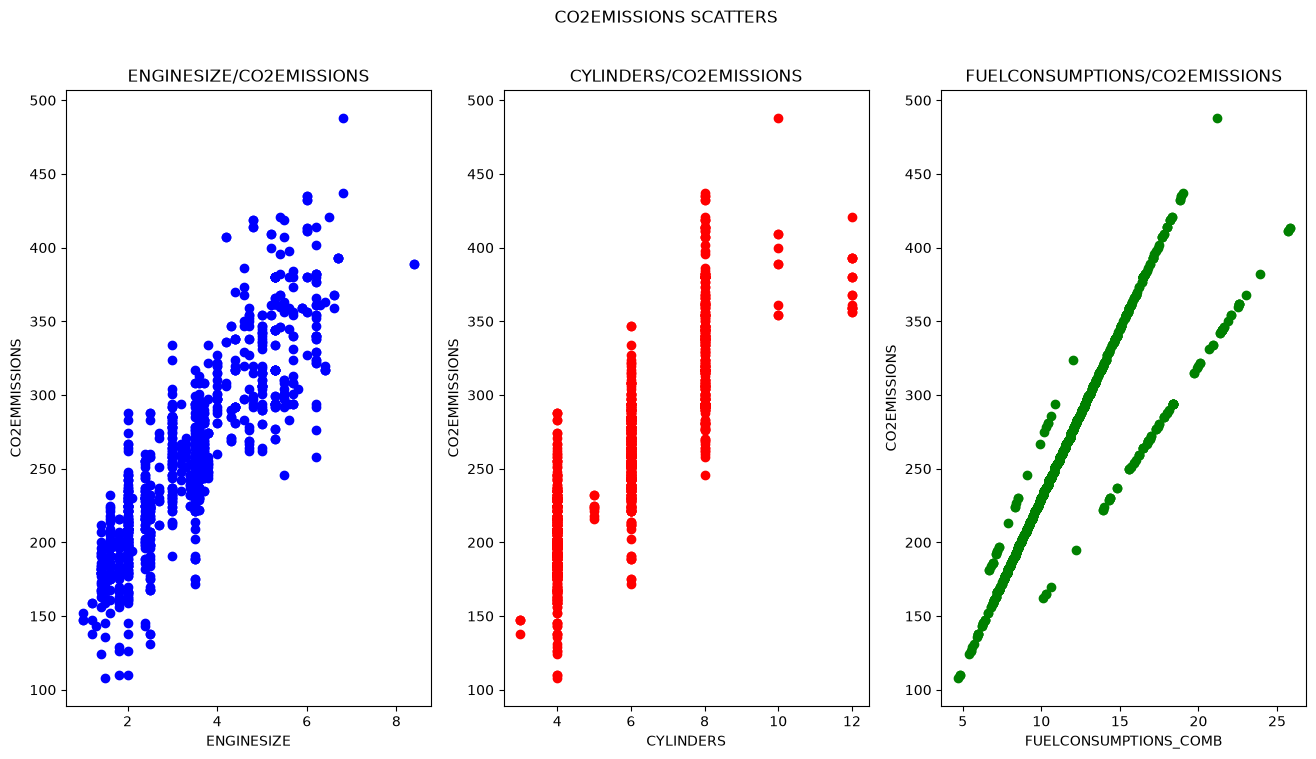

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 8))
fig.suptitle("CO2EMISSIONS SCATTERS")

ax1.set_title("ENGINESIZE/CO2EMISSIONS")
ax1.set_xlabel("ENGINESIZE")
ax1.set_ylabel("CO2EMMISSIONS")
ax1.scatter(cdf["ENGINESIZE"], cdf["CO2EMISSIONS"],color="b")

ax2.set_title("CYLINDERS/CO2EMISSIONS")
ax2.set_xlabel("CYLINDERS")
ax2.set_ylabel("CO2EMMISSIONS")
ax2.scatter(cdf["CYLINDERS"], cdf["CO2EMISSIONS"], color="r")

ax3.set_title("FUELCONSUMPTIONS/CO2EMISSIONS")
ax3.set_xlabel("FUELCONSUMPTIONS_COMB")
ax3.set_ylabel("CO2EMISSIONS")
ax3.scatter(cdf["FUELCONSUMPTION_COMB"], cdf["CO2EMISSIONS"], color="g")

plt.show()

### split our data to train data (80%) and test data (20%)

In [5]:
msk = np.random.rand(len(cdf)) < 0.8

train = cdf[msk]
test = cdf[~msk]

print(train)
print(test)

      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
0            2.0          4                   8.5           196
1            2.4          4                   9.6           221
3            3.5          6                  11.1           255
4            3.5          6                  10.6           244
5            3.5          6                  10.0           230
...          ...        ...                   ...           ...
1061         3.2          6                  11.2           258
1062         3.0          6                  11.8           271
1064         3.0          6                  11.8           271
1065         3.2          6                  11.3           260
1066         3.2          6                  12.8           294

[851 rows x 4 columns]
      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
2            1.5          4                   5.9           136
9            2.4          4                   9.2           212
12           5.9

### calculate the coef and intercept from scratch and draw it on the plot

In [15]:
down = np.sum(np.pow(train["ENGINESIZE"] - np.mean(train["ENGINESIZE"]), 2))
up = np.sum((train["ENGINESIZE"] - np.mean(train["ENGINESIZE"])) * (train["CO2EMISSIONS"] - np.mean(train["CO2EMISSIONS"])))
teta_one = up/down
teta_zero = np.mean(train["CO2EMISSIONS"]) - teta_one * np.mean(train["ENGINESIZE"])
print(teta_one)
print(teta_zero)

39.396507197107226
124.77852358346871


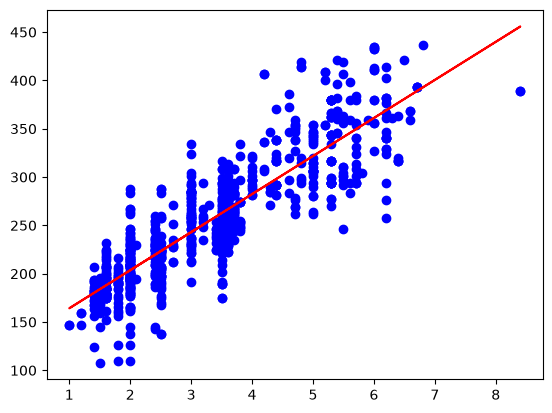

In [7]:
plt.scatter(train["ENGINESIZE"], train["CO2EMISSIONS"], color="b")
plt.plot(train["ENGINESIZE"], teta_zero + teta_one * train["ENGINESIZE"], "r-")
plt.show()

### using scikit-learn madule for the linear regression

In [17]:
from sklearn import linear_model

regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[["ENGINESIZE"]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]])

regr.fit(train_x, train_y)

print(regr.coef_)
print(regr.intercept_)


[[39.3965072]]
[124.77852358]


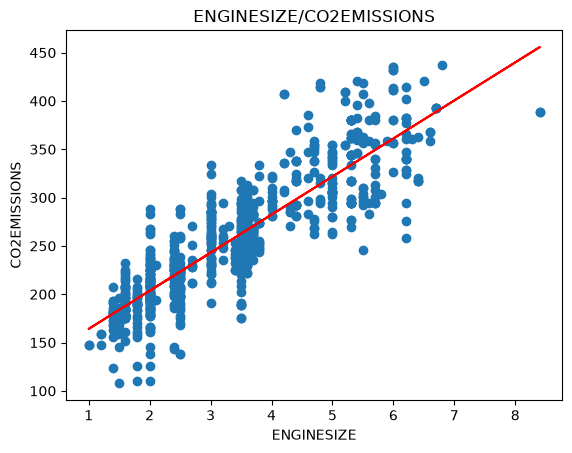

In [26]:
fig, ax = plt.subplots()

ax.set_xlabel("ENGINESIZE")
ax.set_ylabel("CO2EMISSIONS")
ax.set_title("ENGINESIZE/CO2EMISSIONS")

ax.scatter(train_x, train_y)
ax.plot(train_x, train_x * regr.coef_[0][0] + regr.intercept_, "r-")

plt.show()

### testing the regression

In [34]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[["ENGINESIZE"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])
test_y_ = regr.predict(test_x)

print("mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y, test_y_))

mean absolute error: 23.24
Residual sum of squares (MSE): 883.41
R2-score: 0.77


### multiple linear regression

In [51]:
from sklearn import linear_model

regr = linear_model.LinearRegression()

train_x = train[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB"]]
train_y = train[["CO2EMISSIONS"]]

regr.fit(train_x, train_y)
print(regr.coef_)
print(regr.intercept_)

[[10.15113615  7.54277129 10.15476119]]
[61.56049818]


### testing the linear regression

In [50]:
from sklearn.metrics import r2_score

test_x = test[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB"]]
test_y = test[["CO2EMISSIONS"]]
test_y_ = regr.predict(test_x)

print("R2-score: %.2f" % r2_score(test_y, test_y_))

R2-score: 0.85


### polinomial regression

In [56]:
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures

train_x = train[["ENGINESIZE"]]
train_y = train[["CO2EMISSIONS"]]

poly = PolynomialFeatures(2)

train_x_poly = poly.fit_transform(train_x)
train_x_poly

regr = linear_model.LinearRegression()
regr.fit(train_x_poly, train_y)

print(regr.coef_)
print(regr.intercept_)

[[ 0.         51.42911962 -1.60362501]]
[105.64098341]


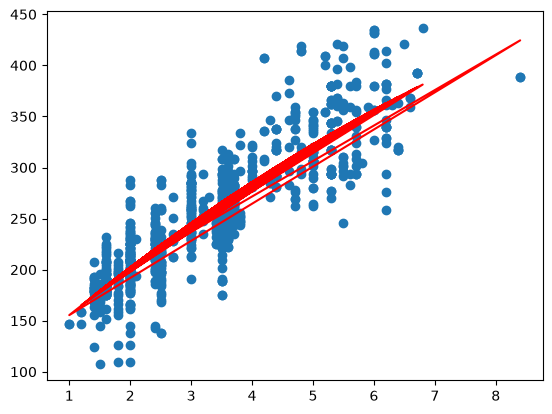

In [61]:
plt.scatter(train_x, train_y)
xx = np.arange(0.0, 10.0, 0.1)
plt.plot(xx, np.pow(xx, 2) * regr.coef_[0][2] + train_x * regr.coef_[0][1] + regr.intercept_, "r-")
plt.show()
